# Carga e Ingesta de Datos (Data understanding)

In [9]:
import pandas as pd

df = pd.read_csv('/content/sample_data/caso1_vetsur.csv', encoding='latin1', sep=',')

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   paciente_id               1400 non-null   object 
 1   sucursal                  1400 non-null   object 
 2   especie                   1400 non-null   object 
 3   raza_registrada           1400 non-null   int64  
 4   edad_mascota_anios        1400 non-null   float64
 5   tipo_atencion             1400 non-null   object 
 6   diagnostico_texto         1400 non-null   object 
 7   medico_id                 1400 non-null   object 
 8   monto_cobrado             1400 non-null   int64  
 9   costo_medicamento         1379 non-null   float64
 10  dias_desde_ultima_visita  1400 non-null   int64  
 11  visitas_historicas        1400 non-null   int64  
 12  tiene_vacunas_al_dia      1400 non-null   int64  
 13  retorno_90d               1400 non-null   int64  
dtypes: float

# Limpieza de encoding y tratamiento de nulos

In [10]:
# Instalamos ftfy, librería para arreglar desastres de encoding
!pip install ftfy

In [11]:
import pandas as pd
from ftfy import fix_text

# Volvemos a cargar el archivo original para partir de cero y limpio
df = pd.read_csv('/content/sample_data/caso1_vetsur.csv', encoding='latin1', sep=',')

# Definimos una función que usa ftfy y luego pasa a minúsculas
def clean_vetsur_text(text):
    if pd.isna(text):
        return text
    # fix_text arregla monstruos como 'Ã ua±oa' a 'Ñuñoa' automáticamente
    cleaned_text = fix_text(str(text))
    # Luego pasamos a minúsculas y quitamos espacios extra
    return cleaned_text.lower().strip()

# Aplicamos la función a las columnas con problemas
cols_to_fix = ['sucursal', 'tipo_atencion', 'diagnostico_texto']
for col in cols_to_fix:
    df[col] = df[col].apply(clean_vetsur_text)

# Rellenar los nulos de costo con la mediana
df['costo_medicamento'] = df['costo_medicamento'].fillna(df['costo_medicamento'].median())

# Verificamos la tablita final
df[['sucursal', 'tipo_atencion', 'diagnostico_texto', 'costo_medicamento']].head(10)

,sucursal,tipo_atencion,diagnostico_texto,costo_medicamento
0,providencia,consulta_general,control_rutina,3500.0
1,ñuñoa,hospitalización,tumor,34600.0
2,peñalolén,hospitalización,control_rutina,31100.0
3,las_condes,consulta_especialidad,control_rutina,24700.0
4,ñuñoa,consulta_general,dermatitis,5800.0
5,peñalolén,consulta_general,fractura,4800.0
6,providencia,cirugía,artritis,74800.0
7,san_miguel,consulta_especialidad,artrítís,17600.0
8,la_florida,consulta_especialidad,esterilización,7500.0
9,pudahuel,cirugía,tumor_c,95100.0


## Normalización estándar (sin tildes ni eñes)

In [12]:
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    # convertimos a string, quitamos espacios y pasamos a minusculas
    texto = str(texto).lower().strip()
    # eliminamos tildes y caracteres especiales (como la ñ) de forma tecnica
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

# aplicamos la normalizacion a todas las columnas de texto
columnas_texto = df.select_dtypes(include=['object']).columns
for col in columnas_texto:
    df[col] = df[col].apply(normalizar_texto)

# verificamos que ahora todo sea texto plano (ej: nunoa, cirugia, maipu)
print("columnas normalizadas exitosamente.")
print(df['sucursal'].unique())
print("tipos de atencion limpios:")
print(df['tipo_atencion'].unique())

print("\nespecies limpias:")
print(df['especie'].unique())

columnas normalizadas exitosamente.
['providencia' 'nunoa' 'penalolen' 'las_condes' 'san_miguel' 'la_florida'
 'pudahuel' 'maipu']
tipos de atencion limpios:
['consulta_general' 'hospitalizacion' 'consulta_especialidad' 'cirugia'
 'venta_producto']

especies limpias:
['gato' 'perro' 'ave' 'exa³tico']


In [13]:
df['especie'] = df['especie'].str.replace('exa³tico', 'exotico', case=False, regex=False)

print("especies limpias (ahora si que si):")
print(df['especie'].unique())

especies limpias (ahora si que si):
['gato' 'perro' 'ave' 'exotico']


# 3. Análisis exploratorio (EDA)

## Bloque 1: Distribución del target objetivo (retorno_90d)

/tmp/ipykernel_51476/1650307479.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='retorno_90d', data=df, palette=vetsur_palette)


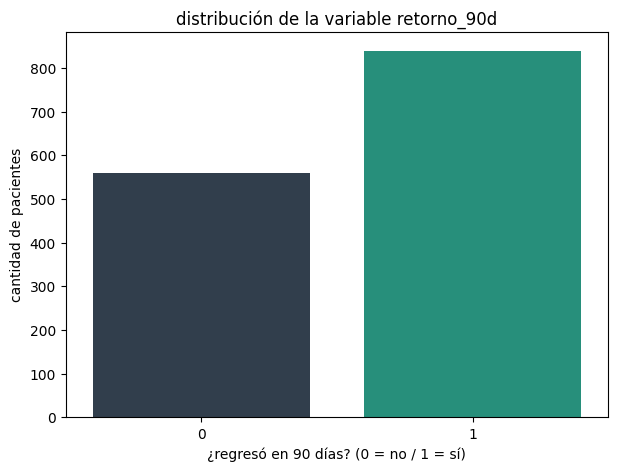

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

vetsur_palette = ["#2c3e50", "#16a085"]

plt.figure(figsize=(7,5))
sns.countplot(x='retorno_90d', data=df, palette=vetsur_palette)

plt.title('distribución de la variable retorno_90d', fontsize=12)
plt.xlabel('¿regresó en 90 días? (0 = no / 1 = sí)')
plt.ylabel('cantidad de pacientes')
plt.show()

## Bloque 2: Matriz de correlación (relación entre variables)

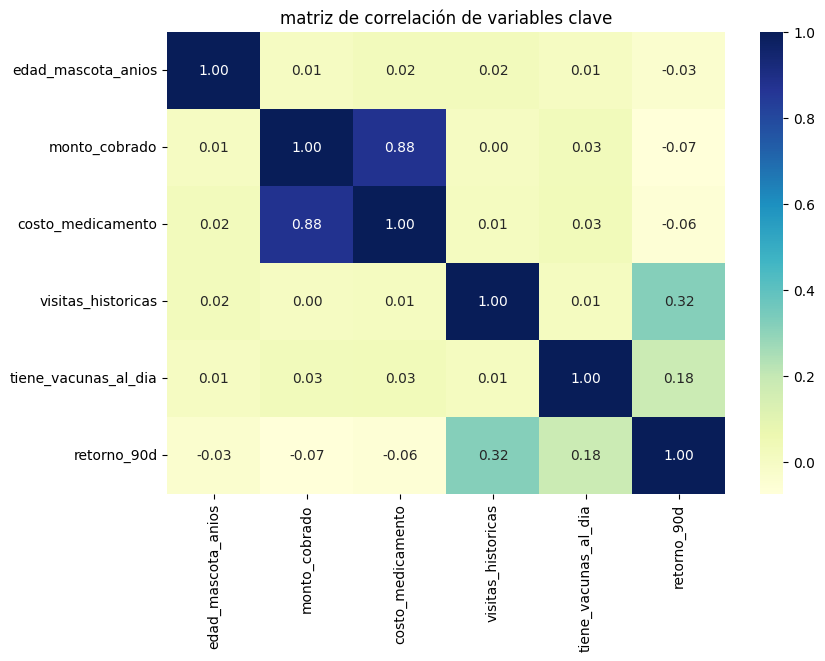

In [15]:
columnas_estudio = [
    'edad_mascota_anios', 'monto_cobrado', 'costo_medicamento',
    'visitas_historicas', 'tiene_vacunas_al_dia', 'retorno_90d'
]

plt.figure(figsize=(9,6))
sns.heatmap(df[columnas_estudio].corr(), annot=True, cmap='YlGnBu', fmt=".2f")

plt.title('matriz de correlación de variables clave', fontsize=12)
plt.show()

## Bloque 3: Hallazgo de negocio (vacunas vs retorno)

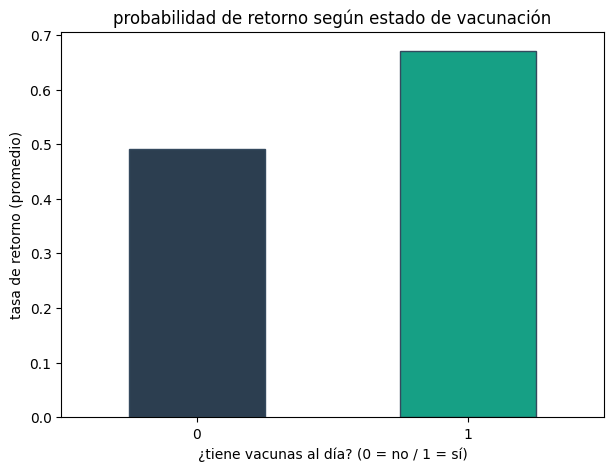

In [16]:
plt.figure(figsize=(7,5))

# graficamos el promedio de retorno agrupado por vacunas
df.groupby('tiene_vacunas_al_dia')['retorno_90d'].mean().plot(
    kind='bar',
    color=vetsur_palette,
    edgecolor='#34495e'
)

plt.title('probabilidad de retorno según estado de vacunación', fontsize=12)
plt.xlabel('¿tiene vacunas al día? (0 = no / 1 = sí)')
plt.ylabel('tasa de retorno (promedio)')
plt.xticks(rotation=0)
plt.show()

# 4. Feature engineering

## Auditoría final de normalización

In [17]:
columnas_chequeo = ['sucursal', 'especie', 'tipo_atencion']

print("--- REVISIÓN DE CATEGORÍAS ---")
for col in columnas_chequeo:
    print(f"\nValores únicos en '{col}':")
    print(df[col].unique())

# buscamos si queda algún caracter que no sea letra, número o espacio
import re
def tiene_caracter_raro(texto):
    if pd.isna(texto): return False
    return bool(re.search(r'[^a-zA-Z0-9\s_]', str(texto)))

print("\n" + "="*30)
print("--- BUSCADOR DE CARÁCTERES BASURA---")
for col in columnas_chequeo:
    errores = df[df[col].apply(tiene_caracter_raro)][col].unique()
    if len(errores) > 0:
        print(f"Se encontró algo en '{col}': {errores}")
    else:
        print(f"'{col}' está 100% limpia.")

--- REVISIÓN DE CATEGORÍAS ---

Valores únicos en 'sucursal':
['providencia' 'nunoa' 'penalolen' 'las_condes' 'san_miguel' 'la_florida'
 'pudahuel' 'maipu']

Valores únicos en 'especie':
['gato' 'perro' 'ave' 'exotico']

Valores únicos en 'tipo_atencion':
['consulta_general' 'hospitalizacion' 'consulta_especialidad' 'cirugia'
 'venta_producto']

--- BUSCADOR DE CARÁCTERES BASURA---
'sucursal' está 100% limpia.
'especie' está 100% limpia.
'tipo_atencion' está 100% limpia.


In [18]:
# con esto ves cuántas especies distintas hay y cuántas veces se repiten
# al tener solo 4 categorías limpias (perro, gato, ave, exotico), nos aseguramos de que el modelo entienda perfectamente que solo existen esos 4 grupos.
df['especie'].value_counts()

,count
especie,
perro,802
gato,451
ave,90
exotico,57


## One-Hot Encoding

In [19]:
# con esto revisamos el "alma" de cada columna antes de transformarla
for col in df.columns:
    print(f"--- Columna: {col} ---")
    print(f"Tipo de dato: {df[col].dtype}")
    print(f"Nulos: {df[col].isnull().sum()}")

    # si es texto, mostramos los valores únicos para ver si hay mas errores de escritura
    if df[col].dtype == 'object':
        print(f"Valores únicos: {df[col].unique()}")
    else:
        # si es numero, mostramos el rango para ver si hay valores locos
        print(f"Rango: min={df[col].min()} | max={df[col].max()}")
    print("\n")

--- Columna: paciente_id ---
Tipo de dato: object
Nulos: 0
Valores únicos: ['pac_00419' 'pac_00001' 'pac_00002' ... 'pac_01396' 'pac_01398'
 'pac_01399']


--- Columna: sucursal ---
Tipo de dato: object
Nulos: 0
Valores únicos: ['providencia' 'nunoa' 'penalolen' 'las_condes' 'san_miguel' 'la_florida'
 'pudahuel' 'maipu']


--- Columna: especie ---
Tipo de dato: object
Nulos: 0
Valores únicos: ['gato' 'perro' 'ave' 'exotico']


--- Columna: raza_registrada ---
Tipo de dato: int64
Nulos: 0
Rango: min=0 | max=1


--- Columna: edad_mascota_anios ---
Tipo de dato: float64
Nulos: 0
Rango: min=0.1 | max=18.0


--- Columna: tipo_atencion ---
Tipo de dato: object
Nulos: 0
Valores únicos: ['consulta_general' 'hospitalizacion' 'consulta_especialidad' 'cirugia'
 'venta_producto']


--- Columna: diagnostico_texto ---
Tipo de dato: object
Nulos: 0
Valores únicos: ['control_rutina' 'tumor' 'dermatitis' 'fractura' 'artritis'
 'esterilizacion' 'tumor_c' 'artritis_c' 'gastroenteritis' 'fractura_c'
 'oti

In [20]:
import pandas as pd

# Borramos los IDs que dijimos que no sirven (para evitar el overfitting)
df_limpio = df.drop(columns=['paciente_id', 'medico_id'])

# Aplicamos el One-Hot Encoding a las columnas de texto
# Esto crea las columnas de 0 y 1 para sucursal, especie, etc.
df_final = pd.get_dummies(df_limpio, columns=['sucursal', 'especie', 'tipo_atencion', 'diagnostico_texto'], drop_first=False)

# Verificamos que ahora todo sea numérico
print("Columnas después del One-Hot Encoding:")
print(df_final.columns.tolist())
print(f"\nAhora tenemos {df_final.shape[1]} columnas listas para el modelo.")
df_final.head()

Columnas después del One-Hot Encoding:
['raza_registrada', 'edad_mascota_anios', 'monto_cobrado', 'costo_medicamento', 'dias_desde_ultima_visita', 'visitas_historicas', 'tiene_vacunas_al_dia', 'retorno_90d', 'sucursal_la_florida', 'sucursal_las_condes', 'sucursal_maipu', 'sucursal_nunoa', 'sucursal_penalolen', 'sucursal_providencia', 'sucursal_pudahuel', 'sucursal_san_miguel', 'especie_ave', 'especie_exotico', 'especie_gato', 'especie_perro', 'tipo_atencion_cirugia', 'tipo_atencion_consulta_especialidad', 'tipo_atencion_consulta_general', 'tipo_atencion_hospitalizacion', 'tipo_atencion_venta_producto', 'diagnostico_texto_artritis', 'diagnostico_texto_artritis_c', 'diagnostico_texto_control_rutina', 'diagnostico_texto_control_rutina_c', 'diagnostico_texto_dermatitis', 'diagnostico_texto_dermatitis_c', 'diagnostico_texto_diabetes', 'diagnostico_texto_diabetes_c', 'diagnostico_texto_esterilizacion', 'diagnostico_texto_esterilizacion_c', 'diagnostico_texto_fractura', 'diagnostico_texto_fra

,raza_registrada,edad_mascota_anios,monto_cobrado,costo_medicamento,dias_desde_ultima_visita,visitas_historicas,tiene_vacunas_al_dia,retorno_90d,sucursal_la_florida,sucursal_las_condes,...,diagnostico_texto_fractura,diagnostico_texto_fractura_c,diagnostico_texto_gastroenteritis,diagnostico_texto_gastroenteritis_c,diagnostico_texto_otitis,diagnostico_texto_otitis_c,diagnostico_texto_parvovirus,diagnostico_texto_parvovirus_c,diagnostico_texto_tumor,diagnostico_texto_tumor_c
0,0,4.7,38900,3500.0,462,3,0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,0.6,234200,34600.0,112,2,0,0,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,1.1,147800,31100.0,42,4,0,1,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,5.9,82600,24700.0,187,5,1,0,False,True,...,False,False,False,False,False,False,False,False,False,False
4,1,0.9,36300,5800.0,111,7,1,1,False,False,...,False,False,False,False,False,False,False,False,False,False


In [21]:
# con esto veo qué columnas quedaron y si son todas numéricas
print("--- INFO DEL DATASET FINAL ---")
print(df_final.info())

print("\n--- PRIMERAS 5 FILAS ---")
print(df_final.head())

--- INFO DEL DATASET FINAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 45 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   raza_registrada                      1400 non-null   int64  
 1   edad_mascota_anios                   1400 non-null   float64
 2   monto_cobrado                        1400 non-null   int64  
 3   costo_medicamento                    1400 non-null   float64
 4   dias_desde_ultima_visita             1400 non-null   int64  
 5   visitas_historicas                   1400 non-null   int64  
 6   tiene_vacunas_al_dia                 1400 non-null   int64  
 7   retorno_90d                          1400 non-null   int64  
 8   sucursal_la_florida                  1400 non-null   bool   
 9   sucursal_las_condes                  1400 non-null   bool   
 10  sucursal_maipu                       1400 non-null   bool   
 11 

# Modelo predictivo y evaluación

## Identificación de variables clave (análisis de importancia)
En esta etapa entrenamos un modelo preliminar con la totalidad de las variables procesadas (41 características) para identificar cuáles tienen un impacto real en el retorno del cliente.

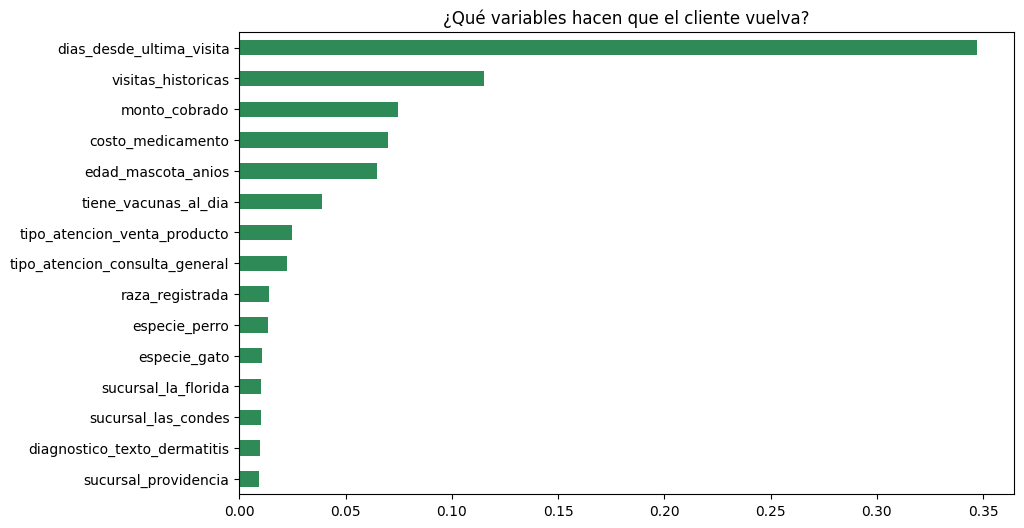

Precisión del modelo: 0.86


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

X = df_final.drop(columns=['retorno_90d'])
y = df_final['retorno_90d']

# Dividimos 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamiento del modelo
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)


importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importancias.head(15).plot(kind='barh', color='seagreen')
plt.title('¿Qué variables hacen que el cliente vuelva?')
plt.gca().invert_yaxis()
plt.show()

print(f"Precisión del modelo: {modelo.score(X_test, y_test):.2f}")

## Entrenamiento del modelo final optimizado (7 variables)

--- MÉTRICAS DEL MODELO OPTIMIZADO (7 VARIABLES) ---
Precisión (Accuracy): 0.85
Recall: 0.89


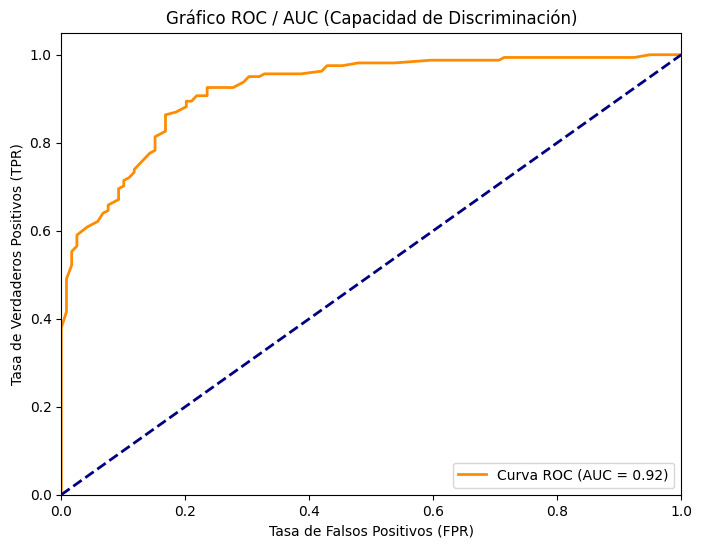


Modelo guardado exitosamente como 'vetsur_rf_optimizado_7vars.pkl'


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Filtramos solo las 7 variables principales identificadas
columnas_top_7 = [
    'dias_desde_ultima_visita',
    'visitas_historicas',
    'monto_cobrado',
    'costo_medicamento',
    'edad_mascota_anios',
    'tiene_vacunas_al_dia',
    'tipo_atencion_venta_producto'
]

X = df_final[columnas_top_7]
y = df_final['retorno_90d']

# 2. Dividimos 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Re-entrenamiento del modelo SOLO con 7 variables
modelo_optimizado = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_optimizado.fit(X_train, y_train)

# 4. Evaluación (Accuracy y Recall)
predicciones = modelo_optimizado.predict(X_test)
print("--- Métricas del modelo optimizado (7 variables) ---")
print(f"Precisión (Accuracy): {accuracy_score(y_test, predicciones):.2f}")
print(f"Recall: {recall_score(y_test, predicciones):.2f}")

# 5. Gráfico ROC y AUC
# Obtenemos las probabilidades de predecir la clase 1 (que el cliente vuelve)
probs = modelo_optimizado.predict_proba(X_test)[:, 1]
fpr, tpr, umbrales = roc_curve(y_test, probs)
auc_score = roc_auc_score(y_test, probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Gráfico ROC (capacidad de discriminación)')
plt.legend(loc="lower right")
plt.show()

# 6. Exportar modelo .pkl
import joblib
joblib.dump(modelo_optimizado, 'vetsur_rf_optimizado_7vars.pkl')
print("\nModelo guardado exitosamente como 'vetsur_rf_optimizado_7vars.pkl'")

**Conclusión del análisis:** Tras observar los resultados, se determinó que el "ruido" de las variables menos importantes podía afectar la generalización del modelo. Por lo tanto, se seleccionaron las **7 variables principales** para construir el modelo final optimizado.

## Comparativa con alternativas

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score
predicciones_bosque = modelo_optimizado.predict(X_test)

# Regresión logística
modelo_lineal = LogisticRegression(max_iter=5000)
modelo_lineal.fit(X_train, y_train)
predicciones_lineal = modelo_lineal.predict(X_test)

# Gradient boosting
modelo_boosting = GradientBoostingClassifier(random_state=42)
modelo_boosting.fit(X_train, y_train)
predicciones_boosting = modelo_boosting.predict(X_test)

print("--- Resultados comparados ---")
print(f"Random forest optimizado -> Acc: {accuracy_score(y_test, predicciones_bosque):.2f} | Recall: {recall_score(y_test, predicciones_bosque):.2f}")
print(f"Regresión logística        -> Acc: {accuracy_score(y_test, predicciones_lineal):.2f} | Recall: {recall_score(y_test, predicciones_lineal):.2f}")
print(f"Boosting                   -> Acc: {accuracy_score(y_test, predicciones_boosting):.2f} | Recall: {recall_score(y_test, predicciones_boosting):.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- RESULTADOS COMPARADOS ---
Random forest     -> Acc: 0.86 | Recall: 0.91
Regresión logística     -> Acc: 0.85 | Recall: 0.86
Boosting          -> Acc: 0.84 | Recall: 0.87


## Validación cruzada

In [24]:
from sklearn.model_selection import cross_val_score

pruebas_acc = cross_val_score(modelo_optimizado, X, y, cv=5)
pruebas_recall = cross_val_score(modelo, X, y, cv=5, scoring='recall')

print("Resultados validación cruzada (7 variables)")
print(f"Accuracy en cada prueba: {pruebas_acc}")
print(f"Promedio accuracy: {pruebas_acc.mean():.2f}")
print("-" * 40)
print(f"Recall en cada prueba: {pruebas_recall}")
print(f"Promedio recall: {pruebas_recall.mean():.2f}")

RESULTADOS VALIDACIÓN CRUZADA
Accuracy en cada prueba: [0.81785714 0.86785714 0.84285714 0.87142857 0.83928571]
Promedio accuracy: 0.85
----------------------------------------
Recall en cada prueba: [0.89880952 0.9047619  0.91071429 0.91071429 0.89285714]
Promedio recall: 0.90


# Exportación de los archivos para deploy

In [25]:
import joblib
import json
from sklearn.ensemble import RandomForestClassifier

# Definimos X (datos) e y (lo que queremos predecir) usando el df_final que ya tiene las 44 columnas
# Asegúrate de haber corrido la celda donde creaste df_final con drop_first=False
X = df_final[columnas_top_7]
y = df_final['retorno_90d']

# Guardamos la lista de columnas EN EL ORDEN REAL del entrenamiento
columnas_vetsur = X.columns.tolist()

# Entrenamos el modelo final con las 7 variables clave
modelo_final = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
modelo_final.fit(X, y)

# Exportamos los archivos para el deploy
joblib.dump(modelo_final, 'modelo_vetsur.pkl')
with open('columnas_vetsur.json', 'w') as f:
    json.dump(columnas_vetsur, f)

print(f"Modelo exportado exitosamente con {len(columnas_vetsur)} columnas.")

Exportado 44 columnas.


# Cálculos justificativos para el informe

In [26]:
# - Cuanto más vuelven los clientes con vacunas
# Comparamos la tasa de retorno de los que tienen vacunas vs los que no.
tasa_retorno_vacuna = df.groupby('tiene_vacunas_al_dia')['retorno_90d'].mean()
diff_puntos = (tasa_retorno_vacuna[1] - tasa_retorno_vacuna[0]) * 100
print(f"1. Diferencia de retorno por vacunas: {diff_puntos:.1f}%")

# - Cuanta plata extra ganariamos con las vacunas
# Calculamos el ingreso si los no-vacunados volvieran tanto como los vacunados.
clientes_sin_vacuna = df[df['tiene_vacunas_al_dia'] == 0]
retornos_actuales = clientes_sin_vacuna['retorno_90d'].sum()
retornos_potenciales = len(clientes_sin_vacuna) * tasa_retorno_vacuna[1]
nuevos_retornos = retornos_potenciales - retornos_actuales
ingreso_extra_estimado = nuevos_retornos * df['monto_cobrado'].mean()
print(f"2. Plata extra si todos se vacunan: ${ingreso_extra_estimado:,.0f}")

# - Que servicios dejan más plata
# Restamos el costo de los remedios al total cobrado para ver el margen real.
df['margen_bruto'] = df['monto_cobrado'] - df['costo_medicamento']
margen_por_tipo = df.groupby('tipo_atencion')['margen_bruto'].mean().sort_values(ascending=False)
print("\n3. Margen real por servicio (lo que nos queda en el bolsillo):")
print(margen_por_tipo)

# - Cuanta plata estamos perdiendo por clientes que no vuelven
# Buscamos a los que llevan > 6 meses sin venir y vemos cuánta plata representan.
fuga_riesgo = df[(df['dias_desde_ultima_visita'] > 180) & (df['retorno_90d'] == 0)]
valor_fuga = len(fuga_riesgo) * fuga_riesgo['monto_cobrado'].mean()
print(f"\n4. Pacientes perdidos (> 6 meses): {len(fuga_riesgo)}")
print(f"   Dinero en riesgo de perderse: ${valor_fuga:,.0f}")

# - Que tan fieles son los clientes que ya han venido más de 5 veces?
# Vemos cuántos son y qué tan probable es que sigan volviendo.
leales = df[df['visitas_historicas'] > 5]
print(f"\n5. Clientes fieles (> 5 visitas): {len(leales)}")
print(f"   Tasa de retorno de estos clientes: {leales['retorno_90d'].mean()*100:.1f}%")

1. Diferencia de retorno por vacunas: 18.0%
2. Plata extra si todos se vacunan: $8,051,006

3. Margen real por servicio (lo que nos queda en el bolsillo):
tipo_atencion
cirugia                  210572.560976
hospitalizacion          150064.754098
consulta_especialidad     48897.419355
consulta_general          27629.951691
venta_producto            22720.765027
Name: margen_bruto, dtype: float64

4. Pacientes perdidos (> 6 meses): 133
   Dinero en riesgo de perderse: $9,903,100

5. Clientes fieles (> 5 visitas): 307
   Tasa de retorno de estos clientes: 82.7%


# Random forest V2 (7 variables más importantes)